In [2]:
import pandas as pd

data = pd.read_csv(
    "data/processed/us_geo_timeseries.csv",
    parse_dates=[
        "time_utc",
        "element_epoch_utc"
    ]
)

print(data.shape)
display(data.head())

(12732, 15)


,time_utc,norad_cat_id,object_name,element_epoch_utc,element_age_hours,sgp4_error,sgp4_error_text,x_teme_km,y_teme_km,z_teme_km,vx_teme_km_s,vy_teme_km_s,vz_teme_km_s,radius_km,element_quality
0,2026-08-01 00:00:00+00:00,19548,TDRS 3,2026-08-01 08:02:58.602336+00:00,8.049612,0,NaN,-6725.273454,-40587.857974,-9038.550810,3.031959,-0.516333,0.114116,42122.427740,good
1,2026-08-01 00:00:00+00:00,20253,FLTSATCOM 8 (USA 46),2026-07-31 18:19:43.953024+00:00,5.671124,0,NaN,10468.889020,39825.632594,9017.061486,-2.977312,0.767888,0.063771,42154.312314,excellent
2,2026-08-01 00:00:00+00:00,21639,TDRS 5,2026-08-01 02:41:38.617728+00:00,2.694060,0,NaN,-33360.053769,25234.363924,5333.065603,-1.876702,-2.349930,-0.638423,42167.616708,excellent
3,2026-08-01 00:00:00+00:00,22314,TDRS 6,2026-07-31 20:31:58.854720+00:00,3.466985,0,NaN,-4388.865482,-40639.747274,-10318.267287,3.057834,-0.323439,-0.037971,42158.247574,excellent
4,2026-08-01 00:00:00+00:00,22787,UFO 2 (USA 95),2026-08-01 02:25:16.476096+00:00,2.421243,0,NaN,39145.775595,-15218.973962,-3689.285363,1.141344,2.796788,0.574858,42161.828018,excellent


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

t = data["time_utc"].min()

snapshot = data[
    data["time_utc"] == t
].copy()

X = snapshot[
    ["x_teme_km", "y_teme_km", "z_teme_km"]
].to_numpy()

print("Timestamp:", t)
print("Satellites:", len(snapshot))
print("Point cloud:", X.shape)

Timestamp: 2026-08-01 00:00:00+00:00
Satellites: 101
Point cloud: (101, 3)


H0 features: 101
H1 features: 5
H2 features: 6


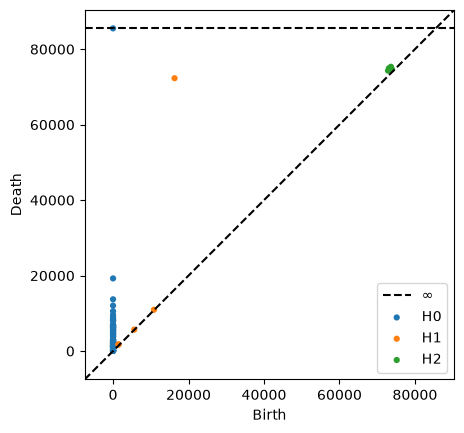

In [4]:
from ripser import ripser
from persim import plot_diagrams

result = ripser(
    X,
    maxdim=2
)

diagrams = result["dgms"]

H0 = diagrams[0]
H1 = diagrams[1]
H2 = diagrams[2]

print("H0 features:", len(H0))
print("H1 features:", len(H1))
print("H2 features:", len(H2))

plot_diagrams(
    diagrams,
    labels=["H0", "H1", "H2"],
    show=True
)

In [5]:
h1 = pd.DataFrame(
    H1,
    columns=["birth_km", "death_km"]
)

h1["persistence_km"] = (
    h1["death_km"] - h1["birth_km"]
)

h1 = h1.sort_values(
    "persistence_km",
    ascending=False
)

display(h1.head(10))

,birth_km,death_km,persistence_km
0,16306.586914,72306.468750,55999.881836
3,1470.751587,1776.835571,306.083984
4,1439.483643,1724.087524,284.603882
1,10841.657227,10947.486328,105.829102
2,5621.378906,5688.855957,67.477051


Using PCA

Variance explained: [0.64750242 0.34612797]


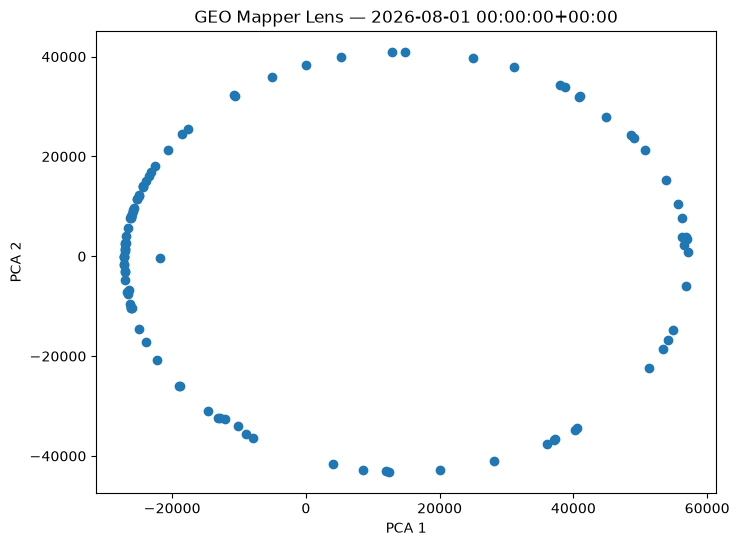

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

lens = pca.fit_transform(X)

print(
    "Variance explained:",
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8, 6))

plt.scatter(
    lens[:, 0],
    lens[:, 1]
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"GEO Mapper Lens — {t}")

plt.show()

In [7]:
import kmapper as km
from sklearn.cluster import DBSCAN

mapper = km.KeplerMapper(verbose=1)

cover = km.Cover(
    n_cubes=10,
    perc_overlap=0.30
)

graph = mapper.map(
    lens,
    X=X,
    cover=cover,
    clusterer=DBSCAN(
        eps=3000,
        min_samples=2
    )
)

print("Mapper nodes:", len(graph["nodes"]))
print("Mapper links:", sum(len(v) for v in graph["links"].values()))

from pathlib import Path
from IPython.display import HTML, display

html_path = Path("geo_mapper.html")

mapper.visualize(
    graph,
    path_html=str(html_path),
    title=f"US GEO Mapper Graph — {t}",
    custom_tooltips=snapshot["object_name"].astype(str).values
)

import webbrowser

webbrowser.open(
    Path("geo_mapper.html").resolve().as_uri()
)

KeplerMapper(verbose=1)
Mapping on data shaped (101, 3) using lens shaped (101, 2)

Creating 100 hypercubes.

Created 32 edges and 35 nodes in 0:00:00.611501.
Mapper nodes: 35
Mapper links: 32
Wrote visualization to: geo_mapper.html


True

In [8]:
for node, members in graph["nodes"].items():

    names = snapshot.iloc[members]["object_name"].tolist()

    print(f"\n{node}")
    print(f"Satellites: {len(names)}")

    for name in names:
        print("  ", name)


cube0_cluster0
Satellites: 2
   ECHOSTAR 16
   ECHOSTAR 18

cube1_cluster0
Satellites: 2
   ECHOSTAR 16
   ECHOSTAR 18

cube2_cluster0
Satellites: 5
   GALAXY 17 (G-17)
   FM-5
   SXM-7
   SXM-8
   SXM-9

cube2_cluster1
Satellites: 2
   GOES 19
   VIASAT-3 F2

cube3_cluster0
Satellites: 15
   GALAXY 3C (G-3C)
   GALAXY 16 (G-16)
   GALAXY 17 (G-17)
   DIRECTV 11
   ICO G1
   GALAXY 19 (G-19)
   FM-5
   DIRECTV 14
   ECHOSTAR 19
   GOES 17
   SXM-7
   SXM-8
   VIASAT-3 F1
   JUPITER 3 (ECHOSTAR 24)
   SXM-9

cube4_cluster0
Satellites: 19
   DIRECTV 5 (TEMPO 1)
   ECHOSTAR 10
   GALAXY 16 (G-16)
   DIRECTV 9S
   DIRECTV 11
   ECHOSTAR 11
   GALAXY 19 (G-19)
   TERRESTAR-1
   DIRECTV 12
   SKYTERRA 1
   SES-3
   ECHOSTAR 17
   DIRECTV 14
   DIRECTV 15
   GOES 16
   ECHOSTAR 19
   ECHOSTAR 23
   AT&T T-16
   ECHOSTAR 25

cube5_cluster0
Satellites: 19
   USA 134
   DIRECTV 5 (TEMPO 1)
   DIRECTV 8
   ECHOSTAR 10
   GALAXY 18 (G-18)
   ECHOSTAR 11
   TERRESTAR-1
   ECHOSTAR 14
   ECHOSTAR 1

Using Latitude and Longitude - in 3D (cosλ,sinλ,ϕ)

In [9]:
snapshot["longitude_deg"] = np.degrees(
    np.arctan2(
        snapshot["y_teme_km"],
        snapshot["x_teme_km"]
    )
)

snapshot["latitude_deg"] = np.degrees(
    np.arctan2(
        snapshot["z_teme_km"],
        np.sqrt(
            snapshot["x_teme_km"]**2 +
            snapshot["y_teme_km"]**2
        )
    )
)

lens = snapshot[
    ["longitude_deg", "latitude_deg"]
].to_numpy()

,object_name,longitude_deg,latitude_deg
0,TDRS 3,-49.026390,-12.390894
1,FLTSATCOM 8 (USA 46),125.653814,12.351472
2,TDRS 5,-166.722896,7.265865
3,TDRS 6,-45.781884,-14.167226
4,UFO 2 (USA 95),29.136923,-5.019976
5,UFO 4 (USA 108),172.492860,9.143173
6,TDRS 7,88.329004,10.314754
7,USA 115 (MILSTAR-1 2),-90.713295,-8.283582
8,USA 134,-112.099816,0.892064
9,UFO 10 (USA 146),-23.074573,-9.697700


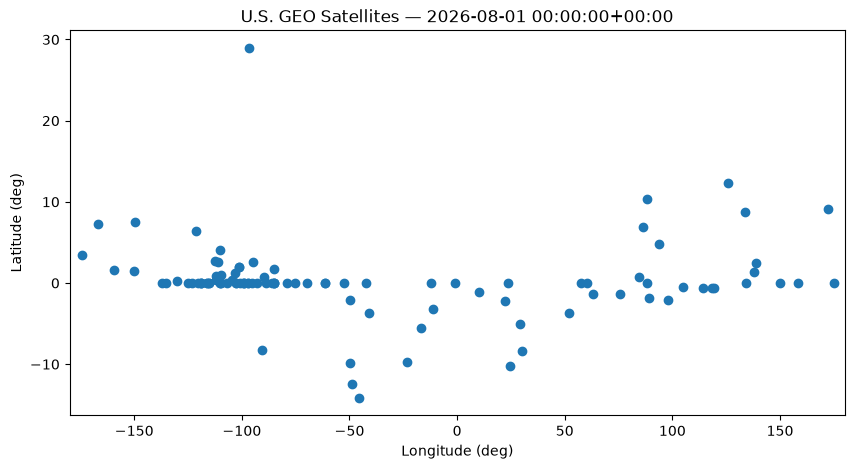

In [10]:
import numpy as np
import astropy.units as u

from astropy.coordinates import TEME, ITRS, CartesianRepresentation
from astropy.time import Time
from astropy.utils import iers

iers.conf.auto_download = False

t = snapshot["time_utc"].iloc[0]

rep = CartesianRepresentation(
    snapshot["x_teme_km"].to_numpy() * u.km,
    snapshot["y_teme_km"].to_numpy() * u.km,
    snapshot["z_teme_km"].to_numpy() * u.km
)

time = Time(t.to_pydatetime())

teme = TEME(
    rep,
    obstime=time
)

itrs = teme.transform_to(
    ITRS(obstime=time)
)

snapshot["longitude_deg"] = (
    itrs.spherical.lon
    .wrap_at(180 * u.deg)
    .deg
)

snapshot["latitude_deg"] = (
    itrs.spherical.lat.deg
)
display(
    snapshot[
        [
            "object_name",
            "longitude_deg",
            "latitude_deg"
        ]
    ].head(20)
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(
    snapshot["longitude_deg"],
    snapshot["latitude_deg"]
)

plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"U.S. GEO Satellites — {t}")

plt.xlim(-180, 180)

plt.show()

In [11]:
lon_rad = np.radians(
    snapshot["longitude_deg"].to_numpy()
)

lat_rad = np.radians(
    snapshot["latitude_deg"].to_numpy()
)

lens = np.column_stack([
    np.cos(lon_rad),
    np.sin(lon_rad),
    lat_rad
])
import kmapper as km
from sklearn.cluster import DBSCAN

mapper = km.KeplerMapper(verbose=1)

cover = km.Cover(
    n_cubes=6,
    perc_overlap=0.4
)

graph = mapper.map(
    lens,
    X=X,
    cover=cover,
    clusterer=DBSCAN(
        eps=3000,
        min_samples=2
    )
)

print("Nodes:", len(graph["nodes"]))
print(
    "Links:",
    sum(len(v) for v in graph["links"].values())
)
from pathlib import Path
from IPython.display import HTML

html_path = Path("geo_mapper_long_lat.html")

mapper.visualize(
    graph,
    path_html=str(html_path),
    title=f"US GEO Mapper Graph — {t}",
    custom_tooltips=snapshot["object_name"].astype(str).values
)

import webbrowser

webbrowser.open(
    Path("geo_mapper_long_lat.html").resolve().as_uri()
)

KeplerMapper(verbose=1)
Mapping on data shaped (101, 3) using lens shaped (101, 3)

Creating 216 hypercubes.

Created 98 edges and 53 nodes in 0:00:00.810163.
Nodes: 53
Links: 98
Wrote visualization to: geo_mapper_long_lat.html


True

In [12]:
import networkx as nx

G = nx.Graph()

for node in graph["nodes"]:
    G.add_node(node)

for node, neighbors in graph["links"].items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

components = sorted(
    nx.connected_components(G),
    key=len,
    reverse=True
)

print("Connected components:", len(components))

for i, component in enumerate(components, 1):
    print(f"Component {i}: {len(component)} nodes")
node_summary = []

for node, members in graph["nodes"].items():

    sats = snapshot.iloc[members]

    node_summary.append({
        "node": node,
        "n_satellites": len(sats),
        "mean_longitude": sats["longitude_deg"].mean(),
        "mean_latitude": sats["latitude_deg"].mean(),
        "satellites": ", ".join(sats["object_name"].tolist())
    })

node_summary = pd.DataFrame(node_summary)

display(
    node_summary.sort_values(
        "n_satellites",
        ascending=False
    )
)
node_summary["n_satellites"].describe()

Connected components: 15
Component 1: 8 nodes
Component 2: 8 nodes
Component 3: 6 nodes
Component 4: 4 nodes
Component 5: 4 nodes
Component 6: 4 nodes
Component 7: 4 nodes
Component 8: 2 nodes
Component 9: 2 nodes
Component 10: 2 nodes
Component 11: 2 nodes
Component 12: 2 nodes
Component 13: 2 nodes
Component 14: 2 nodes
Component 15: 1 nodes


,node,n_satellites,mean_longitude,mean_latitude,satellites
21,cube32_cluster0,35,-101.317840,0.652155,"USA 134, DIRECTV 5 (TEMPO 1), GALAXY 3C (G-3C)..."
20,cube31_cluster0,31,-100.582803,0.346181,"USA 134, ECHOSTAR 10, GALAXY 16 (G-16), DIRECT..."
10,cube19_cluster0,24,-112.721283,0.569540,"USA 134, DIRECTV 5 (TEMPO 1), DIRECTV 8, ECHOS..."
8,cube18_cluster0,21,-112.953321,0.199868,"USA 134, DIRECTV 8, ECHOSTAR 10, GALAXY 18 (G-..."
27,cube39_cluster0,10,-88.777683,0.516193,"GALAXY 3C (G-3C), GALAXY 17 (G-17), ICO G1, FM..."
25,cube38_cluster0,9,-88.112262,0.282205,"GALAXY 17 (G-17), ICO G1, FM-5, GOES 17, SXM-7..."
29,cube40_cluster0,3,87.311373,-0.391127,"TDRS 8, WGS F4 (USA 233), GS-1"
32,cube43_cluster0,3,-48.255494,-12.133061,"TDRS 3, TDRS 6, USA 176 (DSP 22)"
38,cube46_cluster0,3,-48.255494,-12.133061,"TDRS 3, TDRS 6, USA 176 (DSP 22)"
46,cube54_cluster0,3,-48.255494,-12.133061,"TDRS 3, TDRS 6, USA 176 (DSP 22)"


count    53.000000
mean      4.452830
std       7.045364
min       2.000000
25%       2.000000
50%       2.000000
75%       3.000000
max      35.000000
Name: n_satellites, dtype: float64

Using only 2-D (Longitude) (cosλ,sinλ)

In [13]:
lon_rad = np.radians(
    snapshot["longitude_deg"].to_numpy()
)

lens = np.column_stack([
    np.cos(lon_rad),
    np.sin(lon_rad)
])

print(lens.shape)
import kmapper as km
from sklearn.cluster import DBSCAN

mapper = km.KeplerMapper(verbose=1)

cover = km.Cover(
    n_cubes=6,
    perc_overlap=0.35
)

graph = mapper.map(
    lens,
    X=X,
    cover=cover,
    clusterer=DBSCAN(
        eps=3000,
        min_samples=2
    )
)

print("Nodes:", len(graph["nodes"]))
print(
    "Links:",
    sum(len(v) for v in graph["links"].values())
)

(101, 2)
KeplerMapper(verbose=1)
Mapping on data shaped (101, 3) using lens shaped (101, 2)

Creating 36 hypercubes.



Created 25 edges and 31 nodes in 0:00:00.295600.
Nodes: 31
Links: 25


In [14]:
import networkx as nx

G = nx.Graph()

for node in graph["nodes"]:
    G.add_node(node)

for node, neighbors in graph["links"].items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

components = sorted(
    nx.connected_components(G),
    key=len,
    reverse=True
)

print("Connected components:", len(components))
print("Component sizes:", [len(c) for c in components])
sizes = [len(members) for members in graph["nodes"].values()]

pd.Series(sizes).describe()

Connected components: 15
Component sizes: [4, 4, 4, 3, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1]


count    31.000000
mean      3.967742
std       6.311280
min       2.000000
25%       2.000000
50%       2.000000
75%       2.500000
max      32.000000
dtype: float64

In [15]:
results = []

for n_cubes in [4, 5, 6]:
    for overlap in [0.30, 0.40, 0.50]:
        for eps in [3000, 4000, 5000]:

            mapper = km.KeplerMapper(verbose=0)

            graph_test = mapper.map(
                lens,
                X=X,
                cover=km.Cover(
                    n_cubes=n_cubes,
                    perc_overlap=overlap
                ),
                clusterer=DBSCAN(
                    eps=eps,
                    min_samples=2
                )
            )

            G = nx.Graph()

            for node in graph_test["nodes"]:
                G.add_node(node)

            for node, neighbors in graph_test["links"].items():
                for neighbor in neighbors:
                    G.add_edge(node, neighbor)

            components = list(nx.connected_components(G))

            sizes = [
                len(v)
                for v in graph_test["nodes"].values()
            ]

            results.append({
                "n_cubes": n_cubes,
                "overlap": overlap,
                "eps_km": eps,
                "nodes": len(graph_test["nodes"]),
                "edges": G.number_of_edges(),
                "components": len(components),
                "largest_component": max(
                    [len(c) for c in components],
                    default=0
                ),
                "median_node_size": np.median(sizes) if sizes else 0
            })

mapper_tests = pd.DataFrame(results)

display(mapper_tests)

,n_cubes,overlap,eps_km,nodes,edges,components,largest_component,median_node_size
0,4,0.3,3000,23,8,15,3,2.0
1,4,0.3,4000,22,8,14,3,3.0
2,4,0.3,5000,21,8,13,3,3.0
3,4,0.4,3000,26,11,15,3,2.0
4,4,0.4,4000,25,11,14,3,2.0
5,4,0.4,5000,24,11,13,3,3.0
6,4,0.5,3000,32,20,15,4,2.0
7,4,0.5,4000,33,25,14,5,2.0
8,4,0.5,5000,32,25,13,6,2.5
9,5,0.3,3000,23,8,15,3,2.0


In [16]:
results = []
n_cubes = 5
overlap = 0.40
for eps in [3000, 4000, 5000, 6000, 8000, 10000]:

    mapper = km.KeplerMapper(verbose=0)

    graph_test = mapper.map(
        lens,
        X=X,
        cover=km.Cover(
            n_cubes=n_cubes,
            perc_overlap=overlap
        ),
        clusterer=DBSCAN(
            eps=eps,
            min_samples=2
        )
    )

    G = nx.Graph()

    for node in graph_test["nodes"]:
        G.add_node(node)

    for node, neighbors in graph_test["links"].items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    components = list(nx.connected_components(G))

    sizes = [
        len(v)
        for v in graph_test["nodes"].values()
    ]

    results.append({
        "n_cubes": n_cubes,
        "overlap": overlap,
        "eps_km": eps,
        "nodes": len(graph_test["nodes"]),
        "edges": G.number_of_edges(),
        "components": len(components),
        "largest_component": max(
            [len(c) for c in components],
            default=0
        ),
        "median_node_size": np.median(sizes) if sizes else 0
    })

mapper_tests = pd.DataFrame(results)

display(mapper_tests)

,n_cubes,overlap,eps_km,nodes,edges,components,largest_component,median_node_size
0,5,0.4,3000,29,14,15,4,2.0
1,5,0.4,4000,28,15,14,5,2.0
2,5,0.4,5000,27,15,13,5,3.0
3,5,0.4,6000,25,15,11,5,3.0
4,5,0.4,8000,27,22,9,7,4.0
5,5,0.4,10000,22,23,4,9,6.0


Satellites in Mapper: 74
Total satellites: 101
Coverage: 0.7326732673267327


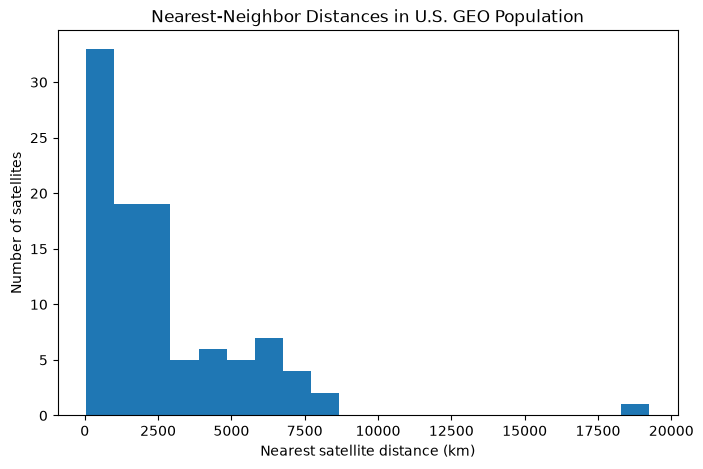

In [17]:
covered = set()

for members in graph["nodes"].values():
    covered.update(members)

print("Satellites in Mapper:", len(covered))
print("Total satellites:", len(X))
print("Coverage:", len(covered) / len(X))
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=2)
nn.fit(X)

distances, indices = nn.kneighbors(X)

nearest = distances[:, 1]

pd.Series(nearest).describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
)
plt.figure(figsize=(8, 5))

plt.hist(nearest, bins=20)

plt.xlabel("Nearest satellite distance (km)")
plt.ylabel("Number of satellites")
plt.title("Nearest-Neighbor Distances in U.S. GEO Population")

plt.show()